# Exp7.2.2 — Frozen-L2 Output Readout Decomposition

This notebook is aggregate-only. It compares the native E2E output LIF against the same native output matrix with the LIF removed, then decomposes threshold/leak/cap/sign effects using a fixed frozen-L2 whole-count affine probe.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
repo = cwd.parent if cwd.name == 'notebooks' else cwd
root = repo / 'notebooks' / 'artifacts' / 'experiment_7_2_2_output_readout_decomposition' / 'output_readout_decomposition_v1'

architecture = pd.read_csv(root / 'architecture_table.csv')
summary = pd.read_csv(root / 'readout_summary.csv')
deltas = pd.read_csv(root / 'paired_deltas.csv')
diagnostics = pd.read_csv(root / 'diagnostics_summary.csv')

print('artifact root:', root)
print('summary rows:', len(summary), 'delta rows:', len(deltas), 'diagnostic rows:', len(diagnostics))

artifact root: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_7_2_2_output_readout_decomposition/output_readout_decomposition_v1
summary rows: 504 delta rows: 546 diagnostic rows: 168


## Test balanced accuracy by readout

`probe_analog_sum` is the exact streaming equivalent of frozen-L2 whole-count + affine LogisticRegression. `native_w_analog_sum` removes only the native output LIF while keeping the E2E output matrix fixed.

In [2]:
test_ba = summary[(summary['split'] == 'test')].copy()
table = test_ba.pivot_table(
    index=['architecture', 'training_family', 'regularization'],
    columns='source',
    values='balanced_accuracy_mean',
)
display(table.round(4))

source                                       native_e2e_lif  \
architecture training_family regularization                   
234x234      e2e_wc          task_only               0.5028   
                             task_plus_reg           0.5167   
             local_tsce      task_only                  NaN   
                             task_plus_reg              NaN   
34x234       e2e_wc          task_only               0.4892   
                             task_plus_reg           0.5092   
             local_tsce      task_only                  NaN   
                             task_plus_reg              NaN   
34x34        e2e_wc          task_only               0.4714   
                             task_plus_reg           0.4575   
             local_tsce      task_only                  NaN   
                             task_plus_reg              NaN   
34x345       e2e_wc          task_only               0.4527   
                             task_plus_reg           0.3875   
             local_tsce      task_only                  NaN   
                             task_plus_reg              NaN   
34x45        e2e_wc          task_only               0.4320   
                             task_plus_reg           0.4316   
             local_tsce      task_only                  NaN   
                             task_plus_reg              NaN   
4x4          e2e_wc          task_only               0.4198   
                             task_plus_reg           0.3859   
             local_tsce      task_only                  NaN   
                             task_plus_reg              NaN   
5x5          e2e_wc          task_only               0.3367   
                             task_plus_reg           0.2776   
             local_tsce      task_only                  NaN   
                             task_plus_reg              NaN   

source                                       native_w_analog_sum  \
architecture training_family regularization                        
234x234      e2e_wc          task_only                    0.5204   
                             task_plus_reg                0.5174   
             local_tsce      task_only                       NaN   
                             task_plus_reg                   NaN   
34x234       e2e_wc          task_only                    0.4977   
                             task_plus_reg                0.5199   
             local_tsce      task_only                       NaN   
                             task_plus_reg                   NaN   
34x34        e2e_wc          task_only                    0.4997   
                             task_plus_reg                0.4824   
             local_tsce      task_only                       NaN   
                             task_plus_reg                   NaN   
34x345       e2e_wc          task_only                    0.4574   
                             task_plus_reg                0.4162   
             local_tsce      task_only                       NaN   
                             task_plus_reg                   NaN   
34x45        e2e_wc          task_only                    0.4522   
                             task_plus_reg                0.4427   
             local_tsce      task_only                       NaN   
                             task_plus_reg                   NaN   
4x4          e2e_wc          task_only                    0.4357   
                             task_plus_reg                0.4164   
             local_tsce      task_only                       NaN   
                             task_plus_reg                   NaN   
5x5          e2e_wc          task_only                    0.3369   
                             task_plus_reg                0.3019   
             local_tsce      task_only                       NaN   
                             task_plus_reg                   NaN   

source                                       probe_analog_sum  \
arc

## Figure 1 — Native E2E readout decomposition

For E2E checkpoints, compare: native LIF, the same native W without LIF, and the refit frozen-L2 affine readout. The first gap is neuron conversion; the second is output-weight optimization.

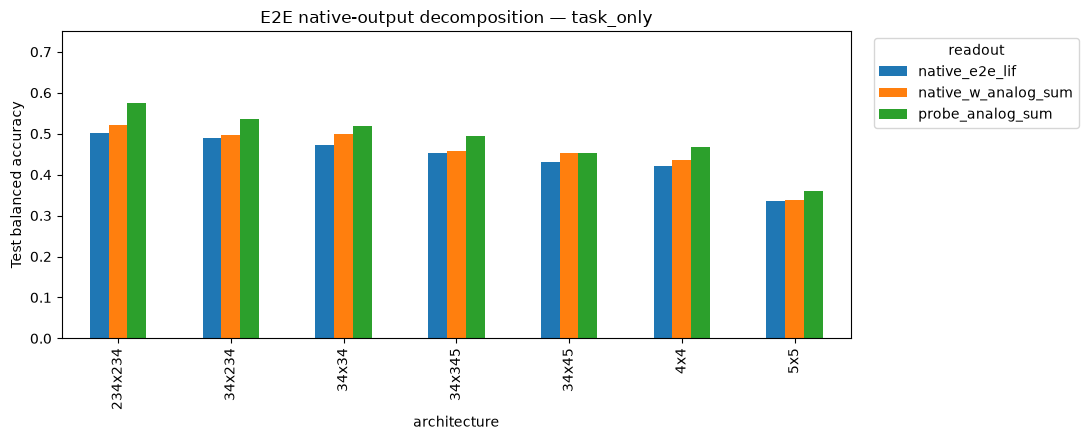

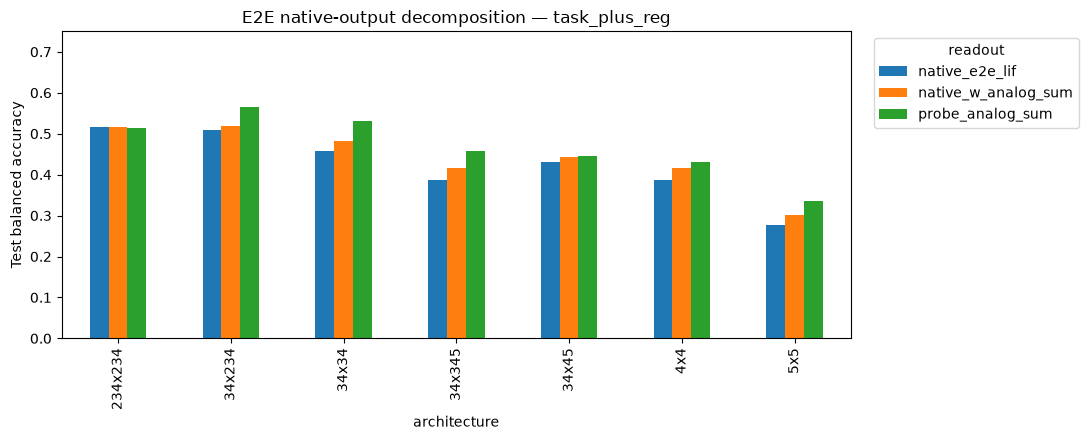

In [3]:
sources = ['native_e2e_lif', 'native_w_analog_sum', 'probe_analog_sum']
e2e = test_ba[(test_ba['training_family'] == 'e2e_wc') & (test_ba['source'].isin(sources))].copy()
for reg in ['task_only', 'task_plus_reg']:
    p = e2e[e2e['regularization'] == reg].pivot(index='architecture', columns='source', values='balanced_accuracy_mean')
    p = p.reindex(architecture['architecture'])
    ax = p[sources].plot(kind='bar', figsize=(11, 4.5))
    ax.set_ylim(0, 0.75)
    ax.set_ylabel('Test balanced accuracy')
    ax.set_title(f'E2E native-output decomposition — {reg}')
    ax.legend(title='readout', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Figure 2 — Fixed-W probe dynamics

Every condition below uses the same fitted `W_probe, b_probe`. This isolates threshold/reset, leak, cap-1 saturation, and loss of signed evidence.

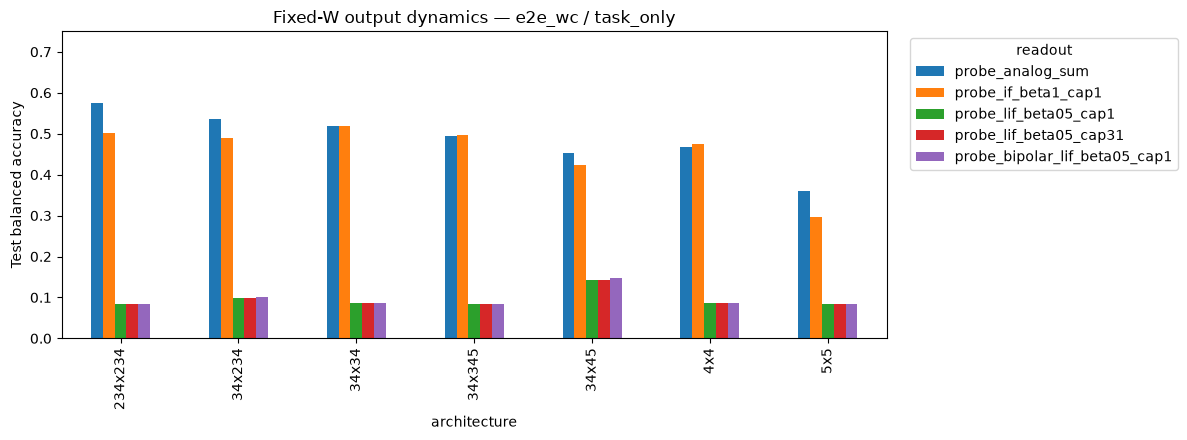

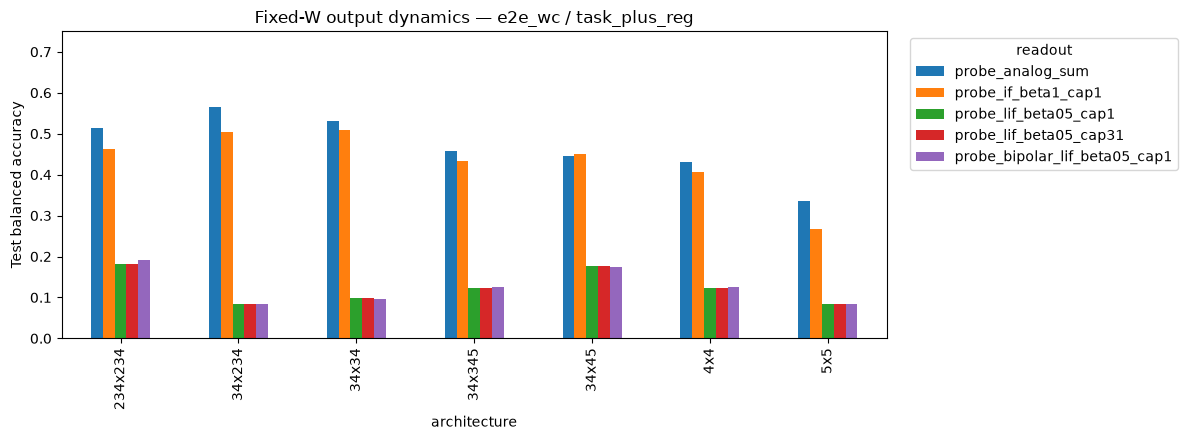

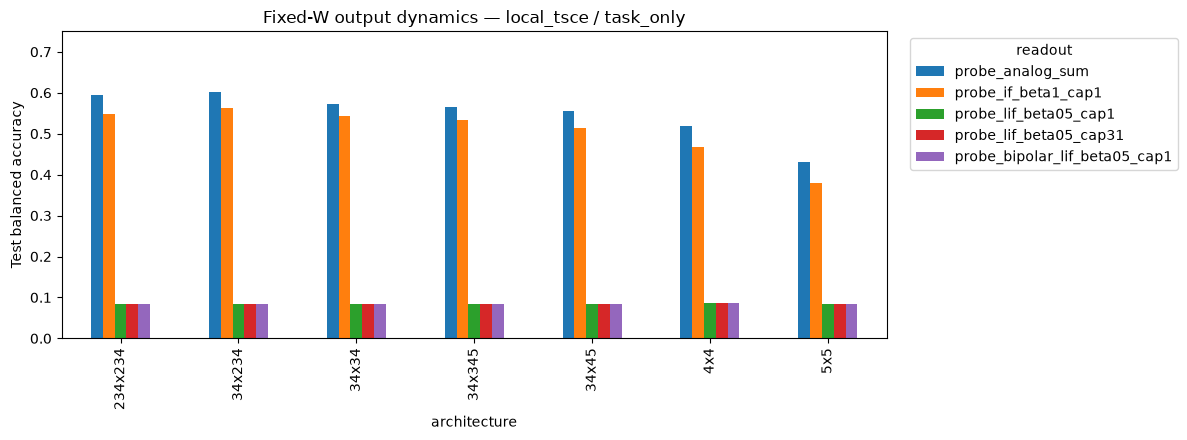

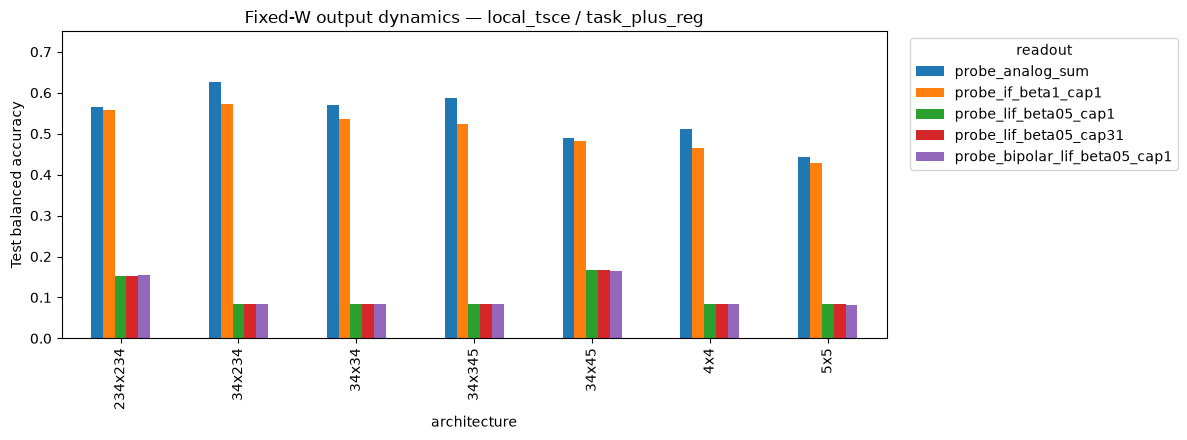

In [4]:
probe_sources = [
    'probe_analog_sum',
    'probe_if_beta1_cap1',
    'probe_lif_beta05_cap1',
    'probe_lif_beta05_cap31',
    'probe_bipolar_lif_beta05_cap1',
]
for family in ['e2e_wc', 'local_tsce']:
    for reg in ['task_only', 'task_plus_reg']:
        q = test_ba[(test_ba['training_family'] == family) & (test_ba['regularization'] == reg) & (test_ba['source'].isin(probe_sources))]
        p = q.pivot(index='architecture', columns='source', values='balanced_accuracy_mean').reindex(architecture['architecture'])
        ax = p[probe_sources].plot(kind='bar', figsize=(12, 4.5))
        ax.set_ylim(0, 0.75)
        ax.set_ylabel('Test balanced accuracy')
        ax.set_title(f'Fixed-W output dynamics — {family} / {reg}')
        ax.legend(title='readout', bbox_to_anchor=(1.02, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

## Figure 3 — Paired BA deltas

Positive delta means the left side of the named contrast performs better.

contrast                                     analog_minus_if  \
architecture training_family regularization                    
234x234      e2e_wc          task_only                0.0709   
                             task_plus_reg            0.0528   
             local_tsce      task_only                0.0475   
                             task_plus_reg            0.0082   
34x234       e2e_wc          task_only                0.0475   
                             task_plus_reg            0.0620   
             local_tsce      task_only                0.0402   
                             task_plus_reg            0.0538   
34x34        e2e_wc          task_only                0.0010   
                             task_plus_reg            0.0224   
             local_tsce      task_only                0.0302   
                             task_plus_reg            0.0336   
34x345       e2e_wc          task_only               -0.0023   
                             task_plus_reg            0.0245   
             local_tsce      task_only                0.0333   
                             task_plus_reg            0.0640   
34x45        e2e_wc          task_only                0.0301   
                             task_plus_reg           -0.0026   
             local_tsce      task_only                0.0396   
                             task_plus_reg            0.0072   
4x4          e2e_wc          task_only               -0.0070   
                             task_plus_reg            0.0237   
             local_tsce      task_only                0.0502   
                             task_plus_reg            0.0484   
5x5          e2e_wc          task_only                0.0657   
                             task_plus_reg            0.0679   
             local_tsce      task_only                0.0496   
                             task_plus_reg            0.0132   

contrast                                     bipolar_minus_lif  if_minus_lif  \
architecture training_family regularization                                    
234x234      e2e_wc          task_only                  0.0000        0.4195   
                             task_plus_reg              0.0085        0.2788   
             local_tsce      task_only                  0.0000        0.4646   
                             task_plus_reg              0.0020        0.4043   
34x234       e2e_wc          task_only                  0.0020        0.3914   
                             task_plus_reg              0.0000        0.4203   
             local_tsce      task_only                  0.0000        0.4791   
                             task_plus_reg              0.0000        0.4885   
34x34        e2e_wc          task_only                  0.0000        0.4301   
                             task_plus_reg             -0.0025        0.4090   
             local_tsce      task_only                  0.0000        0.4594   
                             task_plus_reg              0.0000        0.4532   
34x345       e2e_wc          task_only                  0.0000        0.4134   
                             task_plus_reg              0.0020        0.3096   
             local_tsce      task_only                  0.0000        0.4494   
                             task_plus_reg              0.0000        0.4400   
34x45        e2e_wc          task_only                  0.0060        0.2808   
                             task_plus_reg             -0.0025        0.2724   
             local_tsce      task_only                  0.0000        0.4318   
                             task_plus_reg             -0.0005        0.3150   
4x4          e2e_wc          task_only                  0.0000        0.3894   
                             task_plus_reg              0.0021        0.2847   
             local_tsce      task_only                  0.0000        0.3811   
                             task_plus_reg              0.0000        0.3806   

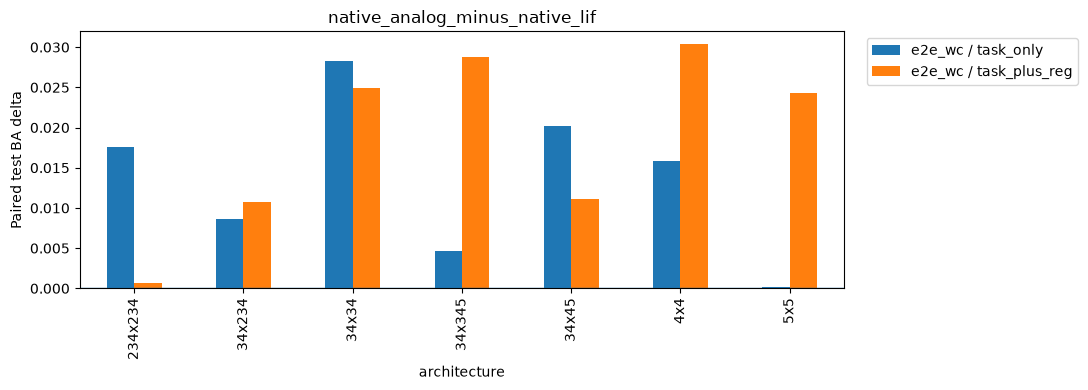

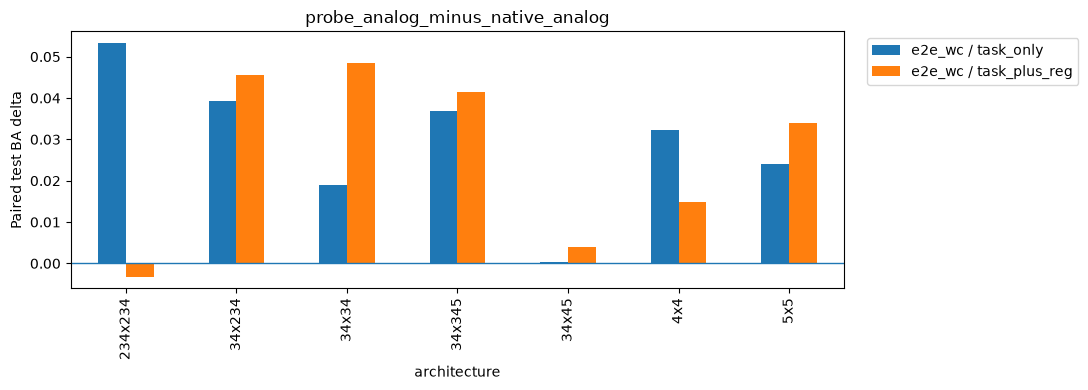

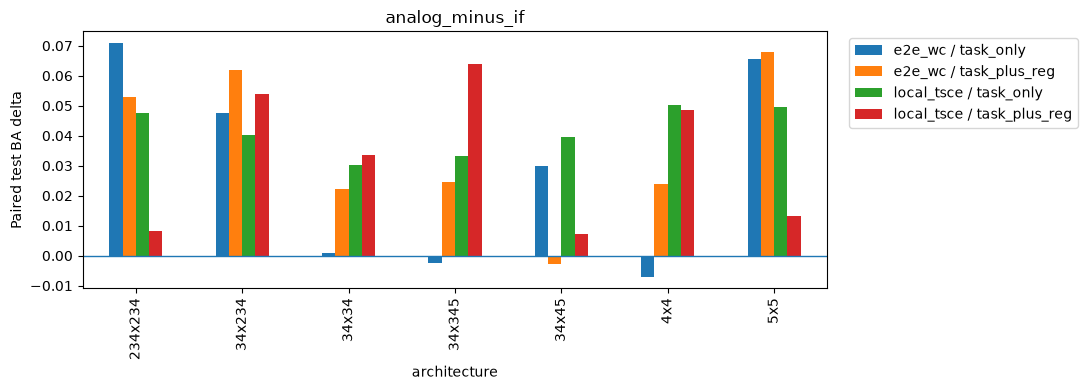

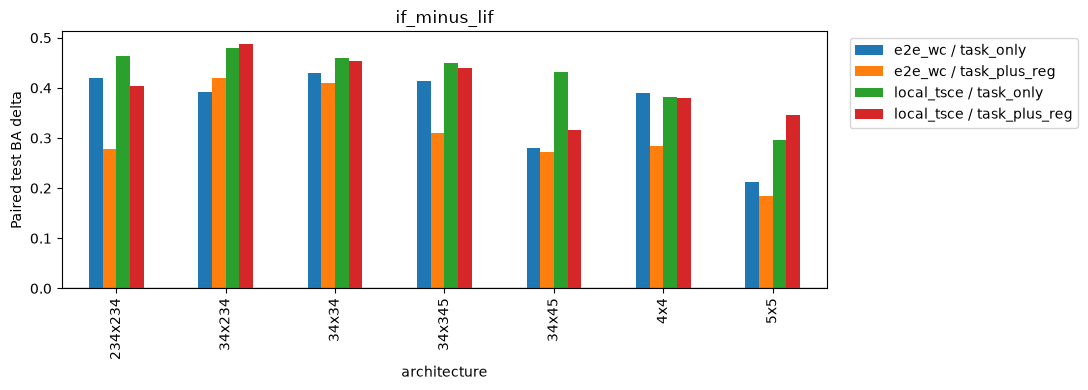

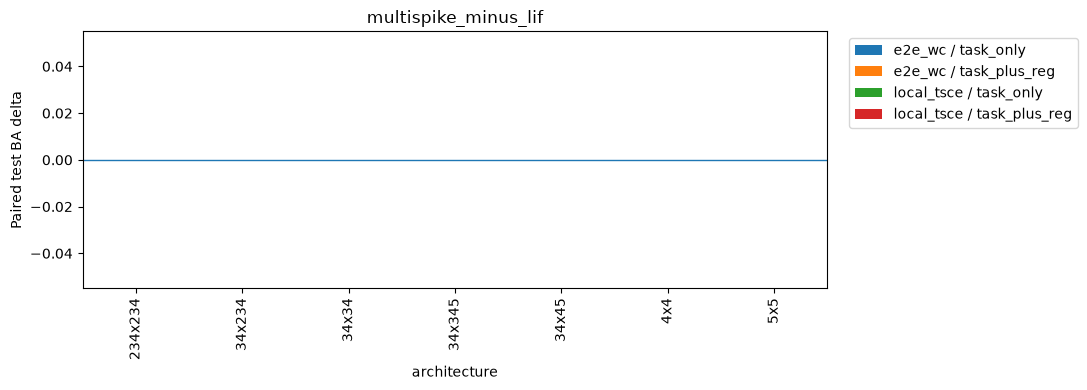

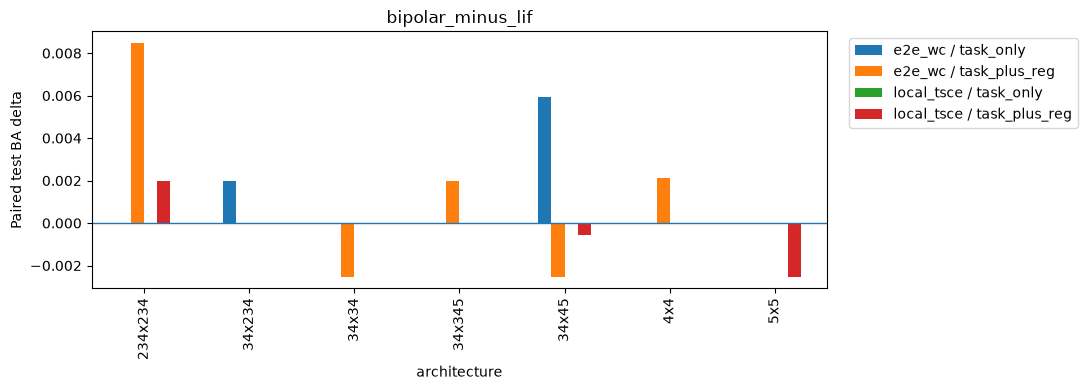

In [5]:
ba_delta = deltas[deltas['metric'] == 'balanced_accuracy'].copy()
primary = [
    'native_analog_minus_native_lif',
    'probe_analog_minus_native_analog',
    'analog_minus_if',
    'if_minus_lif',
    'multispike_minus_lif',
    'bipolar_minus_lif',
]
display(
    ba_delta[ba_delta['contrast'].isin(primary)]
    .pivot_table(index=['architecture', 'training_family', 'regularization'], columns='contrast', values='delta_mean')
    .round(4)
)

for contrast in primary:
    q = ba_delta[ba_delta['contrast'] == contrast].copy()
    if q.empty:
        continue
    q['condition'] = q['training_family'] + ' / ' + q['regularization']
    p = q.pivot(index='architecture', columns='condition', values='delta_mean').reindex(architecture['architecture'])
    ax = p.plot(kind='bar', figsize=(11, 4))
    ax.axhline(0, linewidth=1)
    ax.set_ylabel('Paired test BA delta')
    ax.set_title(contrast)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Output-dynamics diagnostics

Use these aggregates to distinguish signed-evidence loss from cap saturation and leak. In particular inspect `negative_evidence_fraction` and `potential_multi_crossing_fraction_mean`.

In [6]:
diag_cols = [c for c in diagnostics.columns if c.endswith('_mean')]
focus = [c for c in [
    'negative_evidence_fraction_mean',
    'mean_abs_evidence_mean',
    'mean_events_per_valid_output_position_mean',
    'potential_multi_crossing_fraction_mean',
    'zero_spike_sample_fraction_mean',
    'mean_total_output_events_per_sample_mean',
    'positive_event_fraction_mean',
    'negative_event_fraction_mean',
] if c in diagnostics.columns]
display(diagnostics[['architecture', 'training_family', 'regularization', 'source', *focus]].round(4))

,architecture,training_family,regularization,source,negative_evidence_fraction_mean,mean_abs_evidence_mean,mean_events_per_valid_output_position_mean,potential_multi_crossing_fraction_mean,zero_spike_sample_fraction_mean,mean_total_output_events_per_sample_mean,positive_event_fraction_mean,negative_event_fraction_mean
0,234x234,e2e_wc,task_only,native_e2e_lif,0.3939,0.2997,0.1540,0.0282,0.0000,152.7534,NaN,NaN
1,234x234,e2e_wc,task_only,native_w_analog_sum,0.3939,0.2997,NaN,NaN,NaN,NaN,NaN,NaN
2,234x234,e2e_wc,task_only,probe_analog_sum,0.4062,0.0287,NaN,NaN,NaN,NaN,NaN,NaN
3,234x234,e2e_wc,task_only,probe_bipolar_lif_beta05_cap1,0.4062,0.0287,0.0000,0.0000,1.0000,0.0000,0.0,0.0000
4,234x234,e2e_wc,task_only,probe_if_beta1_cap1,0.4062,0.0287,0.0200,0.0000,0.0023,19.8105,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
163,5x5,local_tsce,task_plus_reg,probe_analog_sum,0.3865,0.0295,NaN,NaN,NaN,NaN,NaN,NaN
164,5x5,local_tsce,task_plus_reg,probe_bipolar_lif_beta05_cap1,0.3865,0.0295,0.0000,0.0000,0.9954,0.0091,0.0,0.3333
165,5x5,local_tsce,task_plus_reg,probe_if_beta1_cap1,0.3865,0.0295,0.0239,0.0000,0.0114,23.7329,NaN,NaN
166,5x5,local_tsce,task_plus_reg,probe_lif_beta05_cap1,0.3865,0.0295,0.0000,0.0000,1.0000,0.0000,NaN,NaN


## Interpretation checklist

- Large `native_analog_minus_native_lif`: native W is useful but LIF conversion destroys evidence.
- Large `probe_analog_minus_native_analog`: E2E output matrix itself is poorly optimized for the frozen L2 representation.
- Large `analog_minus_if`: threshold/reset/unipolar binary communication is the dominant loss even without leak.
- Large `if_minus_lif`: membrane leak is an additional major loss.
- Large `multispike_minus_lif`: cap-1 magnitude saturation matters.
- Large `bipolar_minus_lif`: inability to communicate negative class evidence matters.